# **06장. 인공 신경망 모델 설정과 학습 방법**

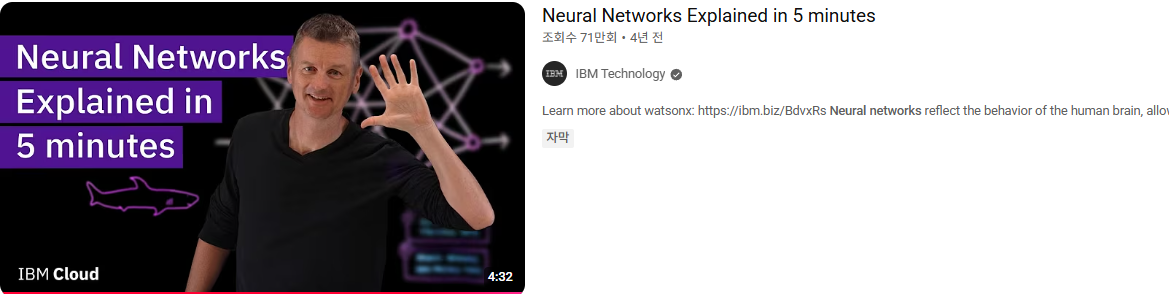

https://www.youtube.com/watch?v=jmmW0F0biz0

이 동영상은 인공 신경망의 구조와 연산 방법을 쉽게 설명합니다.

* Cost Function은 Loss Function의 다른 이름입니다.  


---




[실습 06-01]

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.9 MB/s eta 0:00:00


[실습 06-02]

In [ ]:
np.random.seed(0)

n=1000
x1=np.random.uniform(-3, 3, n)   # 피처1
x2=np.random.uniform(-3, 3, n)   # 피처2

# 타깃: y=f(x1,x2), 복잡한 비선형 함수 적용
y=np.sin(x1) * np.log(x2**2) + np.exp(-x1**2 - x2**2)

print("x1:", x1[:5]); print("x2:", x2[:5]); print("y:", y[:5])   # 처음 5개 출력


x1: [ 0.29288102  1.2911362   0.61658026  0.2692991  -0.4580712 ]
x2: [ 0.55728162 -2.93961783 -0.14504282  1.25262235 -2.73614741]
y: [ 0.33516589  2.0728087  -1.56336879  0.31352531 -0.88977731]


[실습 06-03]

In [ ]:
X=np.stack((x1,x2), axis=1)
y=np.array(y).reshape(-1,1)

[실습 06-04]

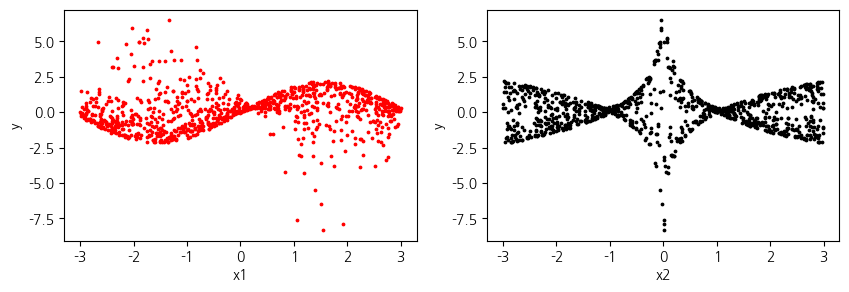

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.scatter(X[:, 0], y, s=3, color="r")  # s는 점의 크기 조절 옵션
plt.xlabel('x1'); plt.ylabel('y')

plt.subplot(1,2,2)
plt.scatter(X[:, 1], y, s=3, color="k")
plt.xlabel('x2'); plt.ylabel('y')
plt.show()

[실습 06-05]

In [ ]:
model = LinearRegression()
model.fit(X, y)

print("가중치(weights) =", model.coef_)
print("편향(bias) =", model.intercept_); print()

y_pred=model.predict(X) # 피쳐 X를 사용하여 모형의 예측값 계산
MSE=mean_squared_error(y, y_pred)
print("평균제곱오차=", MSE)

acc=r2_score(y, y_pred)  # R²예측력 계산
print("R-제곱=", acc)

가중치(weights) = [[0.09877415 0.00971141]]
편향(bias) = [0.08475304]

평균제곱오차= 2.016670831773133
R-제곱= 0.01465792348355377


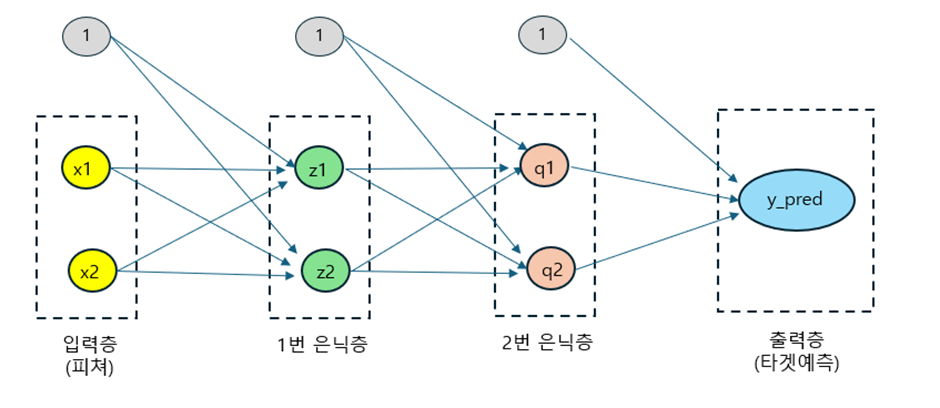

### **텐서플로우 케라스를 사용한 모델 설정 방법**

아래 동영상을 시청해 봅시다. Functional 방법을 설명합니다.

### https://www.youtube.com/watch?v=m5UjSQYqGf0


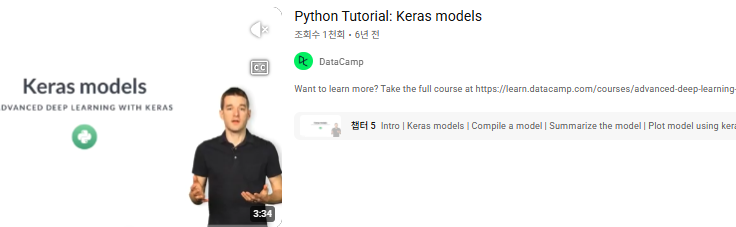

[실습 06-06]

In [ ]:
# 입력
x=Input(shape=(2,))  # shape에 주의
# x=Input(shape=X[0].shape)  # shape 자동 설정

# 선형 변환
z = Dense(units=2)(x)
q = Dense(units=2)(z)
y_pred =Dense(units=1)(q)

# 모델 설정(입력과 출력을 연결)
my_model=Model(inputs=x, outputs=y_pred)
my_model.summary() # 모델 구조 요약

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

[실습 06-07]

In [ ]:
model=Sequential([            # 순차적으로 층을 쌓아가는 모델 설정 방법,
    Input(shape=X[0].shape),  # 입력층
    Dense(2),                 # 1번 은닉층, "units="는 생략 가능"
    Dense(2),                 # 2번 은닉층
    Dense(1)])                # 출력층
model.summary() # 모델 구조 요약

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

[실습 06-08]

In [ ]:
model=Sequential([
    Input(shape=X[0].shape),
    Dense(2, activation='relu'),
    Dense(2, activation='relu'),
    Dense(1, activation='linear')]) # 회귀 문제 출력층은 linear 그대로(활성화 함수 없음)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

[실습 06-09, 06-10, 06-11]

In [ ]:
# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 모델 설정
model=Sequential([
    Input(shape=X[0].shape),
    Dense(2, activation='relu'),
    Dense(2, activation='relu'),
    Dense(1, activation='linear')]) # 회귀 문제 출력층은 linear 그대로(활성화 함수 없음)

# 컴파일(모델 설정 후 실행)
model.compile(optimizer="adam", loss="mse")

# 학습
model.fit(X, y, epochs=300, batch_size=32)  # 학습과정의 주요 통계를 history 객체에 저장

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 4.4904
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7688
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2530
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8924
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6419
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4688
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3500
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2691
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2139
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1762
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1499
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1310
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1167
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1054
Epoch 15/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0958
Epo

[실습 06-12]

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


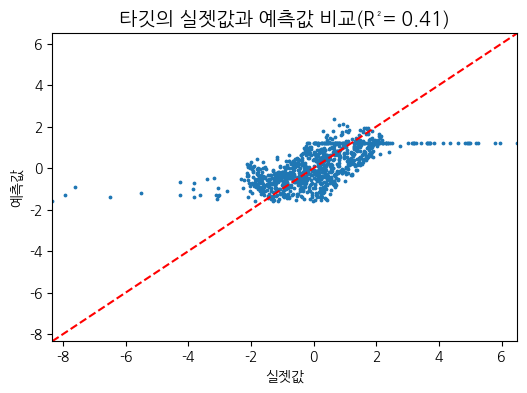

In [ ]:
y_pred=model.predict(X)     # 예측 수행

r2=r2_score(y, y_pred)      # R제곱 계산

plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred, s=3)  # s는 점의 크기 조절
plt.axis([min(y), max(y), min(y), max(y)])

plt.plot([min(y), max(y)], [min(y), max(y)], ls="--", c="r")
plt.title(f'타깃의 실젯값과 예측값 비교(R²= {r2:.2f})', fontsize=14)
plt.xlabel('실젯값'); plt.ylabel('예측값');
plt.show()

[실습 06-13]

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.9313
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7342
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5270
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2906
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0508
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8565
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7342
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6655
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6182
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5859
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5583
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5341
Epoch 13/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5134
Epoch 14/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4960
Epoch 15/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4790
Epo

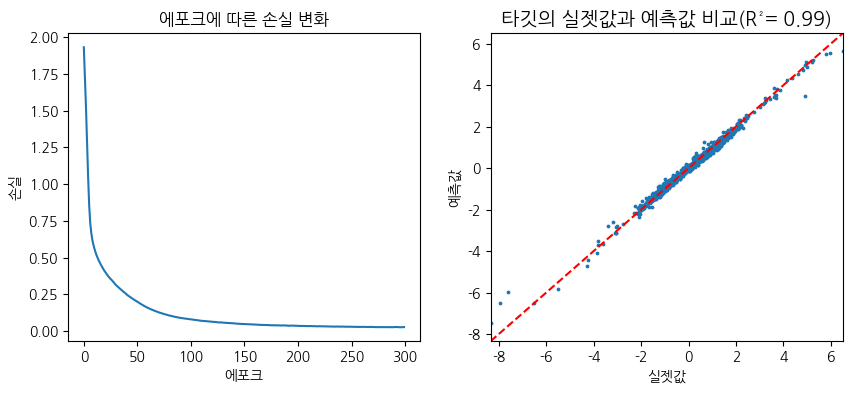

In [ ]:
# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 신경망 모형 재설정(유닛 증가. 은닉층 추가)
model=Sequential([
    Input(shape=X[0].shape),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),  # 3번 은닉층
    Dense(1)    ])

model.compile(optimizer="adam", loss="mse")

history=model.fit(X, y, epochs=300)

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel('에포크')
plt.ylabel('손실')
plt.title('에포크에 따른 손실 변화')

plt.subplot(1, 2, 2)
y_pred = model.predict(X) # 타깃 예측
r2=r2_score(y, y_pred)    # R제곱 계산
plt.scatter(y, y_pred, s=3)
plt.axis([min(y), max(y), min(y), max(y)])
plt.plot([min(y), max(y)], [min(y), max(y)], ls="--", c="r")
plt.title(f'타깃의 실젯값과 예측값 비교(R²= {r2:.2f})', fontsize=14)
plt.xlabel('실젯값'); plt.ylabel('예측값');
plt.show()

[실습 06-14]

In [ ]:
x_new=np.array([[-0.5, 0.2]])  # 예제 입력 (특성 2개)
print("새로운 피처", x_new, "에 대한")
print("타깃의 예측값은 ",  model.predict(x_new), "입니다" )

새로운 피처 [[-0.5  0.2]] 에 대한
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
타깃의 예측값은  [[2.3161328]] 입니다


--------------------------------------------------------------------------------------------------

## **[선택] 텐서 코드로 모델 학습해보기**
* 텐서의 고속 연산을 체험하려면 런타임이 CPU가 아닌 GPU 또는 TPU로 설정되어야 합니다.
* HBM(고대역폭 메모리)을 사용하는 GPU는 더욱 빠릅니다.

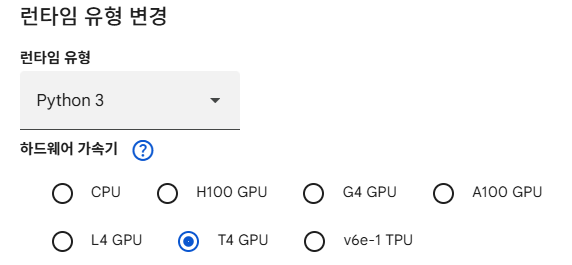

Epoch 1, Loss: 2.1889
Epoch 2, Loss: 1.8853
Epoch 3, Loss: 1.7141
Epoch 4, Loss: 1.5534
Epoch 5, Loss: 1.4109
Epoch 6, Loss: 1.1598
Epoch 7, Loss: 0.9893
Epoch 8, Loss: 0.8412
Epoch 9, Loss: 0.7297
Epoch 10, Loss: 0.6786
Epoch 11, Loss: 0.6445
Epoch 12, Loss: 0.6325
Epoch 13, Loss: 0.6019
Epoch 14, Loss: 0.6075
Epoch 15, Loss: 0.5852
Epoch 16, Loss: 0.5847
Epoch 17, Loss: 0.5698
Epoch 18, Loss: 0.5490
Epoch 19, Loss: 0.5408
Epoch 20, Loss: 0.5345
Epoch 21, Loss: 0.5341
Epoch 22, Loss: 0.5190
Epoch 23, Loss: 0.6554
Epoch 24, Loss: 0.5182
Epoch 25, Loss: 0.4949
Epoch 26, Loss: 0.4903
Epoch 27, Loss: 0.4891
Epoch 28, Loss: 0.4892
Epoch 29, Loss: 0.4845
Epoch 30, Loss: 0.4745
Epoch 31, Loss: 0.4722
Epoch 32, Loss: 0.4829
Epoch 33, Loss: 0.4687
Epoch 34, Loss: 0.4604
Epoch 35, Loss: 0.4476
Epoch 36, Loss: 0.4523
Epoch 37, Loss: 0.4464
Epoch 38, Loss: 0.4470
Epoch 39, Loss: 0.4446
Epoch 40, Loss: 0.4536
Epoch 41, Loss: 0.4333
Epoch 42, Loss: 0.4368
Epoch 43, Loss: 0.4468
Epoch 44, Loss: 0.45

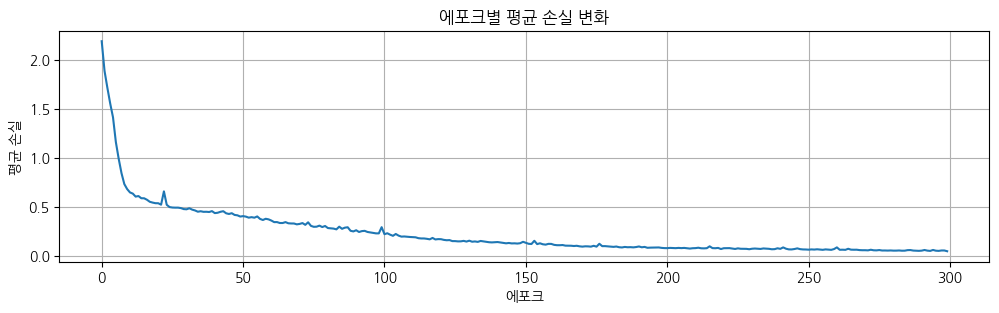

In [ ]:
np.random.seed(42)  # 결과 재현성을 위한 랜덤시드 고정

# 하이퍼 파라미터 설정
epochs = 300
batch_size = 32
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

@tf.function  # 사용자 정의함수 위에 @tf.function을 지정하면 GPU에서 그래프 모드로 빠르게 실행됩니디.
def train_step(x_batch, y_batch): # 벡터 변환과 손실 계산, 경사하강법을 함수로 정의
    with tf.GradientTape() as tape:
        x1 = tf.nn.relu(tf.matmul(x_batch, w1) + b1) # 은닉층 1: 선형변환 후, Relu 활성화 함수 적용
        x2 = tf.nn.relu(tf.matmul(x1, w2) + b2)      # 은닉층 2
        x3 = tf.nn.relu(tf.matmul(x2, w3) + b3)      # 은닉층 3
        y_pred = tf.matmul(x3, w4) + b4              # 출력층
        loss = tf.reduce_mean(tf.square(y_pred - y_batch)) # MSE 손실
    grads = tape.gradient(loss, [w1, b1, w2, b2, w3, b3, w4, b4]) # 텐서 자동 미분
    optimizer.apply_gradients(zip(grads, [w1, b1, w2, b2, w3, b3, w4, b4])) # 경사하강법으로 파라미터 업데이트
    return loss

x_data = tf.cast(X, tf.float32)   # 입력과 타깃 데이터를 텐서로 변환
y_data = tf.cast(y, tf.float32)

dataset = tf.data.Dataset.from_tensor_slices((x_data, y_data))
dataset = dataset.shuffle(len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # 에포크별로 미리 셔플링하여 미니_배치 생성

# 파라미터 초기화
initializer = tf.keras.initializers.GlorotNormal() # 가중치 행렬 초기화 도구
w1 = tf.Variable(initializer([ 2, 16]))  # 차원을 정확하게 지정해야 함
w2 = tf.Variable(initializer([16, 16]))
w3 = tf.Variable(initializer([16, 16]))
w4 = tf.Variable(initializer([16, 1]))
b1 = tf.Variable(tf.zeros([16])) # 편향은 0에서 시작
b2 = tf.Variable(tf.zeros([16]))
b3 = tf.Variable(tf.zeros([16]))
b4 = tf.Variable(tf.zeros([1]))

# 메인 학습 루프
loss_history=[]
for epoch in range(epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataset: # 미리 셔플링된 데이터에서 미나 배치 크기 만큼 꺼냄
        loss = train_step(x_batch, y_batch) # 손실 함수 호출
        epoch_loss += loss                  # 에포크별로 손실 합산, x += y 는 x = x+y 와 같은 코드
    epoch_loss /= tf.cast(len(x_data)/batch_size, tf.float32) # 에포크별 평균 손실 계산
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss.numpy():.4f}")

# 학습 과정 시각화
plt.figure(figsize=(12, 3))
plt.plot(loss_history)
plt.title("에포크별 평균 손실 변화")
plt.xlabel("에포크"); plt.ylabel("평균 손실")
plt.grid(True); plt.show()

사용자 친화적인 케라스의 레이어 인터페이스를 사용하는 것이 편리하고 속도도 더 빠르긴 하지만,

이처럼 "**로우 레벨**" 코드로 직접 텐서를 다루어보면 딥러닝 모델에 대한 여러분의 이해도를 더욱 높일 수 있습니다.